# Visualize Color Jittering and Gaussian Blur Augmentations
This notebook demonstrates the effect of color jittering and gaussian blur augmentations on agricultural test images. These augmentations simulate real-world lighting and image quality variations encountered in agricultural environments.

## 1. Import Required Libraries
Import necessary libraries including PyTorch, torchvision, matplotlib, numpy, and project-specific dataset modules.

In [ ]:
%pip install scikit-image
import sys
import os
SCRIPT_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(SCRIPT_DIR, '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
from torch.utils.data import DataLoader
from src.data.coco_dataset import COCODataset, ImageSegmentationDataset
from src.data.transforms import train_transform, test_transform, target_transform
from src.utils.palette import label2id, palette
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torchvision.transforms as T

## 2. Configure Dataset and DataLoader
Set up the test dataset and DataLoader using agricultural images, similar to the CutMix notebook pipeline.

In [ ]:
# --- Config ---
coco_json = '/Users/rk/Downloads/Thesis/CKA_sweet_pepper_2020_summer/CKA_sweet_pepper_2020_summer.json'
img_root = '/Users/rk/Downloads/Thesis/'
batch_size = 4
num_classes = len(label2id)

# --- Load test set ---
base_dataset = COCODataset(coco_json, img_root, split='test', transform=None)
dataset = ImageSegmentationDataset(base_dataset, label2id=label2id, transform=test_transform, target_transform=target_transform)
test_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# --- Get a batch ---
images, masks, orig_imgs, orig_masks = next(iter(test_loader))

## 3. Define Color Jitter and Gaussian Blur Augmentations
Create torchvision transforms for color jittering (brightness, contrast, saturation, hue) and gaussian blur with parameters reflecting real-world agricultural scenarios.

In [ ]:
# --- Augmentation Transforms ---
# Color jitter values chosen to reflect agricultural lighting variability
# Brightness: 0.6-1.4, Contrast: 0.7-1.3, Saturation: 0.7-1.3, Hue: ±0.05
color_jitter = T.ColorJitter(brightness=0.4, contrast=0.3, saturation=0.3, hue=0.05)
# Gaussian blur simulates out-of-focus, motion, or atmospheric blur
# Kernel size 3-7, sigma 0.5-2.0 (typical for real-world ag scenarios)
gaussian_blur = T.GaussianBlur(kernel_size=5, sigma=(0.5, 2.0))

## 4. Apply Augmentations to Test Batch
Apply the color jitter and gaussian blur augmentations to a batch of test images and store the results for visualization.

In [ ]:
# --- Apply augmentations to normalized tensor images ---
color_jittered_imgs = []
blurred_imgs = []
orig_imgs_np = []
for i in range(batch_size):
    # Use images[i] directly (already normalized and tensor)
    img_tensor = images[i]
    # Convert to numpy and transpose to (H,W,C) for visualization
    img_np = img_tensor.cpu().numpy()
    if img_np.shape[0] == 3:
        img_np = np.transpose(img_np, (1,2,0))
    orig_imgs_np.append(img_np)
    # Convert to PIL for augmentation (de-normalize first for correct color jitter/blur)
    ADE_MEAN = np.array([123.675, 116.280, 103.530]) / 255.0
    ADE_STD = np.array([58.395, 57.120, 57.375]) / 255.0
    img_denorm = (img_np * ADE_STD + ADE_MEAN)
    img_denorm = np.clip(img_denorm, 0, 1)
    pil_img = Image.fromarray((img_denorm * 255).astype(np.uint8))
    # Color jitter
    jittered = color_jitter(pil_img)
    color_jittered_imgs.append(np.array(jittered) / 255.0)
    # Gaussian blur
    blurred = gaussian_blur(pil_img)
    blurred_imgs.append(np.array(blurred) / 255.0)

## 5. Visualize Augmented Images
Display original, color jittered, and gaussian blurred images side by side for each sample in the batch using matplotlib.

In [ ]:
fig, axs = plt.subplots(batch_size, 3, figsize=(18, 6 * batch_size))
for i in range(batch_size):
    # Original image (de-normalized for visualization)
    img_np = images[i].cpu().numpy()
    if img_np.shape[0] == 3:
        img_np = np.transpose(img_np, (1,2,0))
    ADE_MEAN = np.array([123.675, 116.280, 103.530]) / 255.0
    ADE_STD = np.array([58.395, 57.120, 57.375]) / 255.0
    img_denorm = (img_np * ADE_STD + ADE_MEAN)
    img_denorm = np.clip(img_denorm, 0, 1)
    axs[i,0].imshow(img_denorm)
    axs[i,0].set_title(f'Original Image [{i}]')
    axs[i,0].axis('off')
    print(f'Original Image [{i}] - min: {img_denorm.min():.3f}, max: {img_denorm.max():.3f}, mean: {img_denorm.mean():.3f}')

    # Color jittered image
    axs[i,1].imshow(color_jittered_imgs[i])
    axs[i,1].set_title('Color Jittered')
    axs[i,1].axis('off')
    print(f'Color Jittered [{i}] - min: {color_jittered_imgs[i].min():.3f}, max: {color_jittered_imgs[i].max():.3f}, mean: {color_jittered_imgs[i].mean():.3f}')

    # Gaussian blurred image
    axs[i,2].imshow(blurred_imgs[i])
    axs[i,2].set_title('Gaussian Blurred')
    axs[i,2].axis('off')
    print(f'Gaussian Blurred [{i}] - min: {blurred_imgs[i].min():.3f}, max: {blurred_imgs[i].max():.3f}, mean: {blurred_imgs[i].mean():.3f}')

plt.tight_layout()
plt.show()

In [ ]:
# Debug: Print image statistics and show originals (scaled)
for i in range(batch_size):
    raw_img = orig_imgs[i] if 'orig_imgs' in locals() else images[i]
    if torch.is_tensor(raw_img):
        img_np = raw_img.cpu().numpy()
        if img_np.shape[0] == 3:
            img_np = np.transpose(img_np, (1,2,0))
        raw_img = img_np
    if raw_img.max() > 1.1:
        scaled_img = raw_img.astype(np.float32) / 255.0
    else:
        scaled_img = raw_img.astype(np.float32)
    print(f'Scaled Image {i}: shape={scaled_img.shape}, min={scaled_img.min():.3f}, max={scaled_img.max():.3f}, mean={scaled_img.mean():.3f}')
    plt.figure(figsize=(4,4))
    plt.imshow(scaled_img)
    plt.title(f'Scaled Image [{i}] (0-1 range)')
    plt.axis('off')
    plt.show()

In [ ]:
# Visualize raw images from dataset (before scaling)
for i in range(batch_size):
    raw_img = orig_imgs[i] if 'orig_imgs' in locals() else images[i]
    if torch.is_tensor(raw_img):
        img_np = raw_img.cpu().numpy()
        if img_np.shape[0] == 3:
            img_np = np.transpose(img_np, (1,2,0))
        raw_img = img_np
    print(f'Raw Image {i}: shape={raw_img.shape}, min={raw_img.min():.3f}, max={raw_img.max():.3f}, mean={raw_img.mean():.3f}')
    plt.figure(figsize=(4,4))
    plt.imshow(raw_img.astype(np.uint8) if raw_img.max() > 1.1 else raw_img)
    plt.title(f'Raw Image [{i}]')
    plt.axis('off')
    plt.show()

In [ ]:
# Visualize and use scaled images (0-1 range) for augmentation
for i in range(batch_size):
    raw_img = orig_imgs[i] if 'orig_imgs' in locals() else images[i]
    # Convert torch tensor to numpy if needed
    if torch.is_tensor(raw_img):
        img_np = raw_img.cpu().numpy()
        # If shape is (C,H,W), convert to (H,W,C)
        if img_np.shape[0] == 3:
            img_np = np.transpose(img_np, (1,2,0))
        raw_img = img_np
    # Scale to [0, 1] if in 0-255 range
    if raw_img.max() > 1.1:
        scaled_img = raw_img.astype(np.float32) / 255.0
    else:
        scaled_img = raw_img.astype(np.float32)
    print(f'Scaled Image {i}: shape={scaled_img.shape}, min={scaled_img.min():.3f}, max={scaled_img.max():.3f}, mean={scaled_img.mean():.3f}')
    plt.figure(figsize=(4,4))
    plt.imshow(scaled_img)
    plt.title(f'Scaled Image [{i}] (0-1 range)')
    plt.axis('off')
    plt.show()

Image 0: Not blurred
RandomGaussianBlur [0] - min: 0.000, max: 1.000, mean: 0.435
Image 1: Not blurred
RandomGaussianBlur [1] - min: 0.004, max: 1.000, mean: 0.466
Image 2: Blurred with sigma=1.76
RandomGaussianBlur [2] - min: 0.027, max: 1.000, mean: 0.494
Image 3: Not blurred
RandomGaussianBlur [3] - min: 0.000, max: 1.000, mean: 0.494


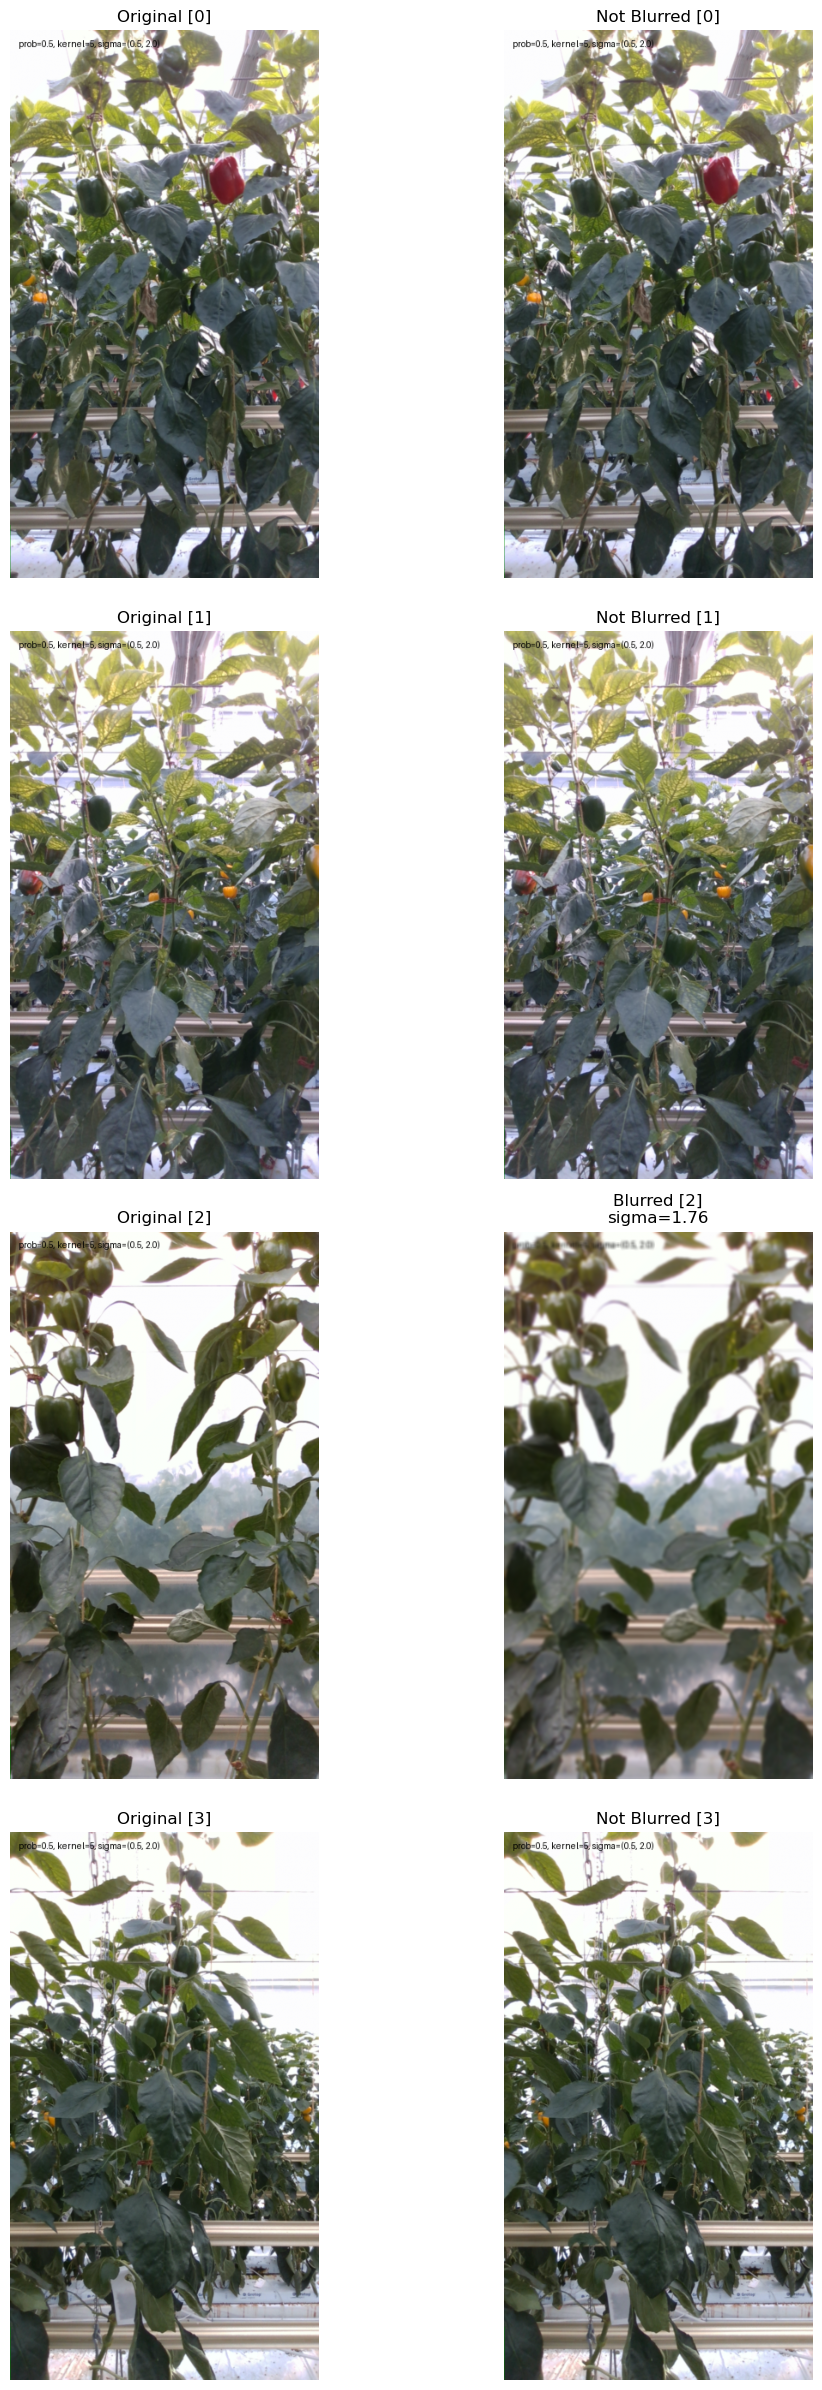

In [15]:
# Simulate RandomGaussianBlur in a pipeline using the test dataloader batch
import random
import torchvision.transforms.functional as F
from PIL import ImageDraw, ImageFont

class RandomGaussianBlur(object):
    def __init__(self, prob, kernel_size, sigma=None):
        self.prob = prob
        self.kernel_size = kernel_size
        self.sigma = sigma
    def __call__(self, img):
        if random.random() < self.prob:
            # Randomly sample sigma if it's a tuple
            if isinstance(self.sigma, tuple):
                sigma_val = random.uniform(self.sigma[0], self.sigma[1])
            else:
                sigma_val = self.sigma
            img_blur = F.gaussian_blur(img, kernel_size=self.kernel_size, sigma=sigma_val)
            return img_blur, sigma_val
        return img, None

# Parameters (simulate args)
blur_prob = 0.5
blur_kernel = 5
blur_sigma = (0.5, 2.0)

# Use images from test_loader batch (already loaded above)
sim_blur = RandomGaussianBlur(blur_prob, blur_kernel, blur_sigma)

sim_blurred_imgs = []
img_denorms = []
blurred_info = []
for i in range(batch_size):
    # De-normalize for PIL
    img_tensor = images[i]
    img_np = img_tensor.cpu().numpy()
    if img_np.shape[0] == 3:
        img_np = np.transpose(img_np, (1,2,0))
    ADE_MEAN = np.array([123.675, 116.280, 103.530]) / 255.0
    ADE_STD = np.array([58.395, 57.120, 57.375]) / 255.0
    img_denorm = (img_np * ADE_STD + ADE_MEAN)
    img_denorm = np.clip(img_denorm, 0, 1)
    pil_img = Image.fromarray((img_denorm * 255).astype(np.uint8))
    # Draw parameters on image (black text for visibility)
    draw = ImageDraw.Draw(pil_img)
    text = f'prob={blur_prob}, kernel={blur_kernel}, sigma={blur_sigma}'
    try:
        font = ImageFont.truetype("DejaVuSans-Bold.ttf", 24)
    except Exception:
        font = ImageFont.load_default()
    draw.text((10, 10), text, fill=(0,0,0), font=font)
    img_denorms.append(np.array(pil_img) / 255.0)
    # Apply simulated random gaussian blur and record sigma
    blurred, sigma_val = sim_blur(pil_img)
    sim_blurred_imgs.append(np.array(blurred) / 255.0)
    blurred_info.append(sigma_val)

# Visualize results and print blur info
fig, axs = plt.subplots(batch_size, 2, figsize=(12, 6 * batch_size))
for i in range(batch_size):
    axs[i,0].imshow(img_denorms[i])
    axs[i,0].set_title(f'Original [{i}]')
    axs[i,0].axis('off')
    axs[i,1].imshow(sim_blurred_imgs[i])
    if blurred_info[i] is not None:
        axs[i,1].set_title(f'Blurred [{i}]\nsigma={blurred_info[i]:.2f}')
        print(f'Image {i}: Blurred with sigma={blurred_info[i]:.2f}')
    else:
        axs[i,1].set_title(f'Not Blurred [{i}]')
        print(f'Image {i}: Not blurred')
    axs[i,1].axis('off')
    print(f'RandomGaussianBlur [{i}] - min: {sim_blurred_imgs[i].min():.3f}, max: {sim_blurred_imgs[i].max():.3f}, mean: {sim_blurred_imgs[i].mean():.3f}')

plt.tight_layout()
plt.show()